# Task 3 - Klasyfikacja obrazów CIFAR-10 z użyciem PyTorch

**Autor:** Maciej Kiendyś
**Przydzielona grupa:** MLP, ponieważ ostatnia cyfra indeksu to 0.

Celem zadania jest implementacja własnej sieci neuronowej do klasyfikacji obrazów ze zbioru CIFAR-10 bez korzystania z gotowych modeli pretrained. W notebooku wykonano analizę danych, implementację modelu MLP, serię eksperymentów z hiperparametrami, ocenę najlepszego modelu oraz wizualizację wyników.

## 1. Import bibliotek i konfiguracja

W tej części importuję potrzebne biblioteki oraz ustawiam ziarno losowości, żeby wyniki były bardziej powtarzalne.

In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from src.data import load_datasets, create_loaders, dataset_statistics, get_class_names
from src.models import MLPClassifier
from src.train import fit_model, evaluate
from src.evaluate import model_metrics, plot_confusion_matrix
from src.plots import plot_class_distribution, show_sample_images, plot_series_histories, show_misclassified

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 2. Opis zbioru danych

CIFAR-10 to zbiór 60000 kolorowych obrazów o rozdzielczości 32x32 piksele podzielonych na 10 klas. Zbiór składa się z 50000 obrazów treningowych i 10000 testowych. Klasy to: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

In [2]:
class_names = get_class_names()
train_set, val_set, test_set, analysis_train = load_datasets(data_dir='data', val_ratio=0.1, normalize=True)
stats = dataset_statistics(analysis_train)

print('Kształt tensora wszystkich obrazów treningowych:', stats['shape'])
print('Minimalna wartość piksela:', stats['min_pixel'])
print('Maksymalna wartość piksela:', stats['max_pixel'])
print('Średnia RGB:', [round(x, 4) for x in stats['mean']])
print('Odchylenie standardowe RGB:', [round(x, 4) for x in stats['std']])
print('Liczba klas:', len(class_names))
print('Nazwy klas:', class_names)

c:\Users\Michał\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Kształt tensora wszystkich obrazów treningowych: (50000, 3, 32, 32)
Minimalna wartość piksela: 0.0
Maksymalna wartość piksela: 1.0
Średnia RGB: [0.4914, 0.4822, 0.4465]
Odchylenie standardowe RGB: [0.247, 0.2435, 0.2616]
Liczba klas: 10
Nazwy klas: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. Analiza zbioru danych

Najpierw sprawdzam rozkład klas i wyświetlam przykładowe obrazy. Dzięki temu można potwierdzić, że dane zostały poprawnie wczytane i że klasy są zbalansowane.

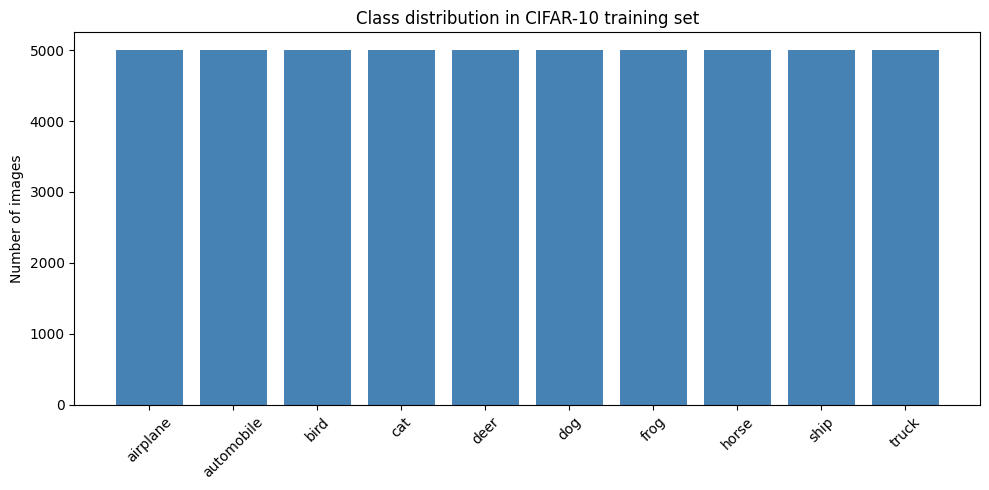

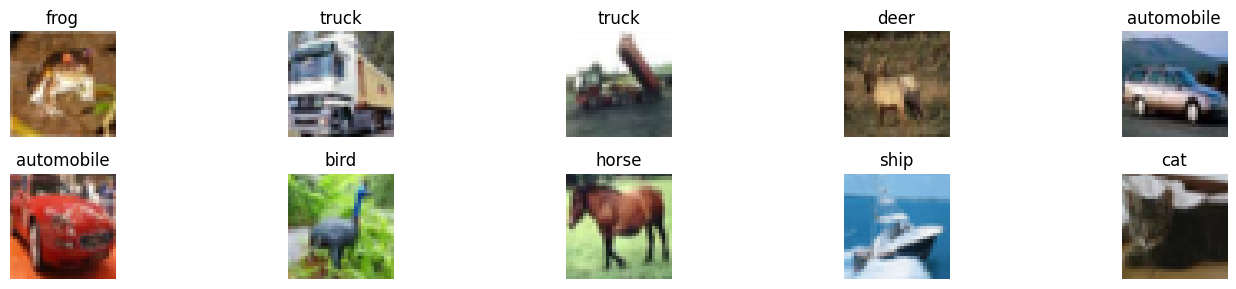

In [3]:
plot_class_distribution(stats['class_counts'], class_names)
show_sample_images(analysis_train, class_names, n=10)

## 4. Przygotowanie danych do treningu

Do modelu MLP obrazy są podawane jako tensory, a następnie spłaszczane wewnątrz modelu. Zastosowałem podział części treningowej na zbiór treningowy i walidacyjny w proporcji 90/10.

In [4]:
def get_loaders_for_batch_size(batch_size):
    train_loader, val_loader, test_loader = create_loaders(train_set, val_set, test_set, batch_size=batch_size)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_loaders_for_batch_size(128)
print('Liczba batchy train:', len(train_loader))
print('Liczba batchy val:', len(val_loader))
print('Liczba batchy test:', len(test_loader))

Liczba batchy train: 352
Liczba batchy val: 40
Liczba batchy test: 79


## 5. Architektura sieci MLP

Dla mojego numeru indeksu wymagana jest sieć MLP. Model zawiera warstwę `Flatten`, dwie warstwy ukryte, funkcje aktywacji ReLU oraz dropout. Na końcu znajduje się warstwa wyjściowa z 10 neuronami odpowiadającymi klasom CIFAR-10.

In [5]:
model = MLPClassifier(hidden1=512, hidden2=256, dropout=0.3).to(device)
print(model)

MLPClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)


### Uzasadnienie architektury

Warstwa `Flatten` zamienia obraz 3x32x32 na wektor długości 3072, ponieważ sieć MLP operuje na danych jednowymiarowych. Dwie warstwy ukryte pozwalają modelowi uczyć się bardziej złożonych zależności niż pojedyncza warstwa. Funkcja ReLU przyspiesza uczenie i wprowadza nieliniowość, a dropout ogranicza przeuczenie.

## 6. Funkcja straty i optymalizator

W zadaniu klasyfikacji wieloklasowej używam funkcji straty `CrossEntropyLoss`, ponieważ działa ona bezpośrednio na logitach wyjściowych modelu i indeksach klas. Jako optymalizator wybrałem Adam, ponieważ zazwyczaj daje stabilne uczenie i jest wygodny do eksperymentów z różnymi hiperparametrami.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 7. Funkcje pomocnicze do eksperymentów

Poniżej definiuję funkcje, które uruchamiają trening dla wybranych hiperparametrów i zapisują wyniki w wygodnej tabeli.

In [7]:
def run_experiment_series(series_name, values, build_config, epochs=8):
    results = []
    for value in values:
        config = build_config(value)
        batch_size = config.get('batch_size', 128)
        train_loader, val_loader, test_loader = get_loaders_for_batch_size(batch_size)

        model = MLPClassifier(
            hidden1=config.get('hidden1', 512),
            hidden2=config.get('hidden2', 256),
            dropout=config.get('dropout', 0.3)
        ).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=config.get('lr', 0.001))

        model, history, best_val_acc, elapsed = fit_model(
            model, train_loader, val_loader, criterion, optimizer, device, epochs=epochs
        )

        test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

        results.append({
            'series': series_name,
            'label': value,
            'config': config,
            'best_val_acc': best_val_acc,
            'test_acc': test_acc,
            'test_loss': test_loss,
            'time_sec': elapsed,
            'history_train_loss': history['train_loss'],
            'history_val_loss': history['val_loss'],
            'history_train_acc': history['train_acc'],
            'history_val_acc': history['val_acc'],
            'test_preds': test_preds,
            'test_labels': test_labels,
            'model_state_dict': model.state_dict()
        })
        print(f"{series_name} | {value} | val_acc={best_val_acc:.4f} | test_acc={test_acc:.4f}")
    return pd.DataFrame(results)


def final_table(df):
    table = df[['label', 'best_val_acc', 'test_acc', 'test_loss', 'time_sec']].copy()
    table['best_val_acc'] = table['best_val_acc'].round(4)
    table['test_acc'] = table['test_acc'].round(4)
    table['test_loss'] = table['test_loss'].round(4)
    table['time_sec'] = table['time_sec'].round(1)
    return table.sort_values(by='test_acc', ascending=False).reset_index(drop=True)

## 8. Seria 1 - wpływ learning rate

W pierwszej serii zmieniam tylko learning rate, a pozostałe parametry pozostawiam stałe. Chcę sprawdzić, jaka wartość daje najlepsze i najbardziej stabilne uczenie.

In [8]:
lr_values = [0.0001, 0.001, 0.01]
lr_results = run_experiment_series(
    'learning_rate',
    lr_values,
    lambda value: {'lr': value, 'batch_size': 128, 'hidden1': 512, 'hidden2': 256, 'dropout': 0.3},
    epochs=8
)
final_table(lr_results)

learning_rate | 0.0001 | val_acc=0.5334 | test_acc=0.5246
learning_rate | 0.001 | val_acc=0.5262 | test_acc=0.5100
learning_rate | 0.01 | val_acc=0.1617 | test_acc=0.1649


,label,best_val_acc,test_acc,test_loss,time_sec
0,0.0001,0.5334,0.5246,1.3504,79.1
1,0.0010,0.5262,0.5100,1.3773,79.0
2,0.0100,0.1617,0.1649,2.1203,78.8


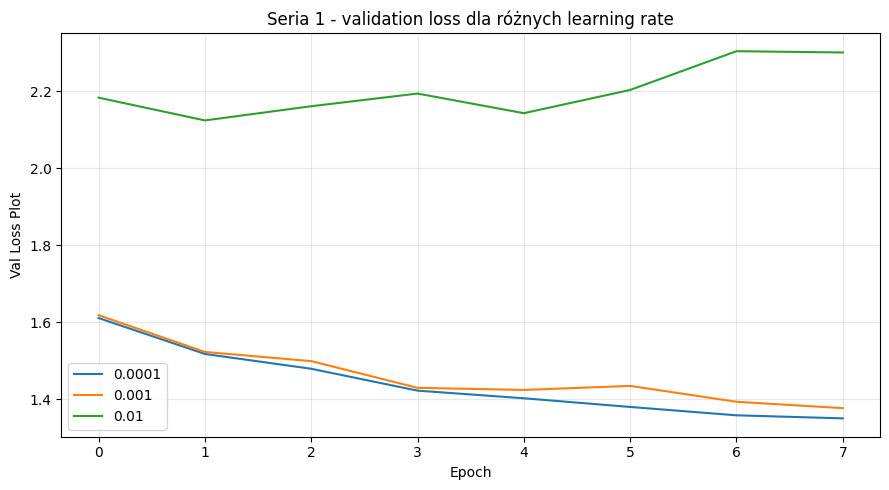

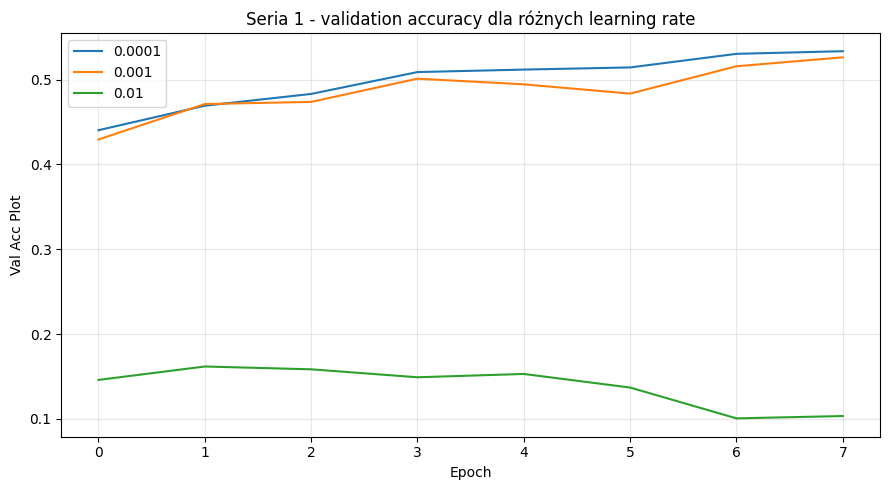

In [9]:
plot_series_histories(
    lr_results.rename(columns={'history_val_loss': 'val_loss_plot'}).assign(val_loss_plot=lr_results['history_val_loss']),
    'val_loss_plot',
    'Seria 1 - validation loss dla różnych learning rate'
)
plot_series_histories(
    lr_results.rename(columns={'history_val_acc': 'val_acc_plot'}).assign(val_acc_plot=lr_results['history_val_acc']),
    'val_acc_plot',
    'Seria 1 - validation accuracy dla różnych learning rate'
)

**Wniosek:** Zbyt mały learning rate zwykle spowalnia uczenie, a zbyt duży może powodować niestabilność. Najlepszy wybór wybiorę na podstawie końcowego accuracy na zbiorze testowym i przebiegu krzywych walidacyjnych.

## 9. Seria 2 - wpływ batch size

W drugiej serii zmieniam batch size. Parametr ten wpływa jednocześnie na stabilność gradientu, szybkość uczenia oraz zużycie pamięci.

In [10]:
batch_values = [32, 64, 128]
batch_results = run_experiment_series(
    'batch_size',
    batch_values,
    lambda value: {'lr': 0.001, 'batch_size': value, 'hidden1': 512, 'hidden2': 256, 'dropout': 0.3},
    epochs=8
)
final_table(batch_results)

batch_size | 32 | val_acc=0.4650 | test_acc=0.4662
batch_size | 64 | val_acc=0.4925 | test_acc=0.4908
batch_size | 128 | val_acc=0.5070 | test_acc=0.5009


,label,best_val_acc,test_acc,test_loss,time_sec
0,128,0.5070,0.5009,1.3954,77.0
1,64,0.4925,0.4908,1.4417,77.4
2,32,0.4650,0.4662,1.5306,85.5


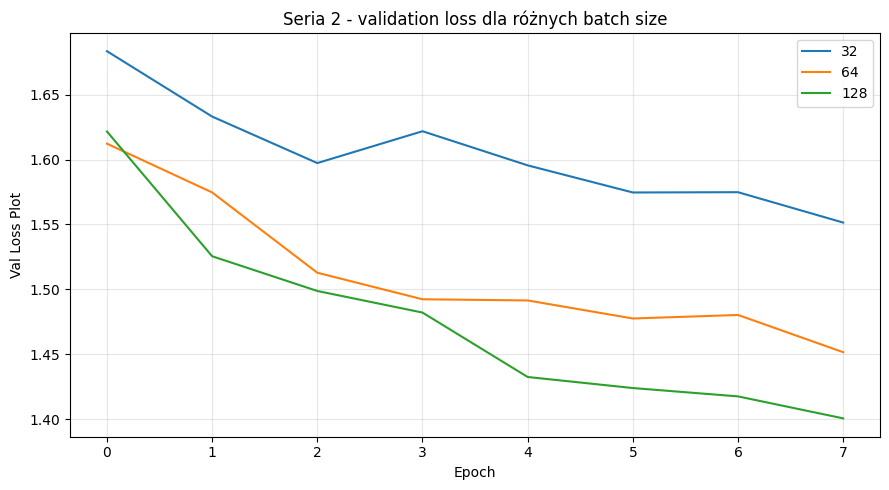

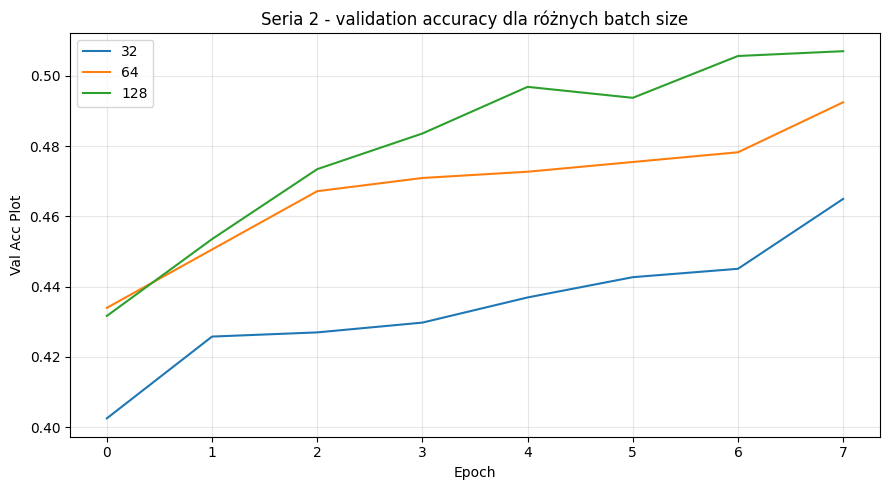

In [11]:
plot_series_histories(
    batch_results.rename(columns={'history_val_loss': 'val_loss_plot'}).assign(val_loss_plot=batch_results['history_val_loss']),
    'val_loss_plot',
    'Seria 2 - validation loss dla różnych batch size'
)
plot_series_histories(
    batch_results.rename(columns={'history_val_acc': 'val_acc_plot'}).assign(val_acc_plot=batch_results['history_val_acc']),
    'val_acc_plot',
    'Seria 2 - validation accuracy dla różnych batch size'
)

**Wniosek:** Mniejsze batch size często poprawia uogólnianie, ale wydłuża trening. Większe batch size zwykle działa szybciej, lecz może dawać trochę słabsze wyniki końcowe.

## 10. Seria 3 - wpływ liczby neuronów w warstwach ukrytych

To seria obowiązkowa dla mojej grupy. Zmieniam liczbę neuronów w warstwach ukrytych, aby sprawdzić, jak pojemność modelu wpływa na wynik.

In [12]:
hidden_values = [64, 128, 256, 512]
hidden_results = run_experiment_series(
    'hidden_neurons',
    hidden_values,
    lambda value: {'lr': 0.001, 'batch_size': 128, 'hidden1': value, 'hidden2': max(value // 2, 32), 'dropout': 0.3},
    epochs=8
)
final_table(hidden_results)

hidden_neurons | 64 | val_acc=0.4752 | test_acc=0.4748
hidden_neurons | 128 | val_acc=0.4975 | test_acc=0.4895
hidden_neurons | 256 | val_acc=0.5092 | test_acc=0.5074
hidden_neurons | 512 | val_acc=0.5023 | test_acc=0.4938


,label,best_val_acc,test_acc,test_loss,time_sec
0,256,0.5092,0.5074,1.4002,75.9
1,512,0.5023,0.4938,1.4429,77.7
2,128,0.4975,0.4895,1.4362,75.9
3,64,0.4752,0.4748,1.4987,77.1


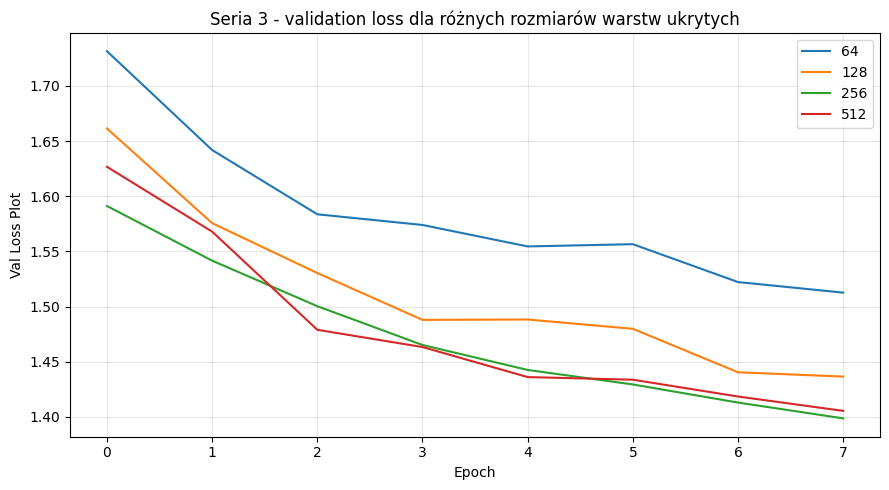

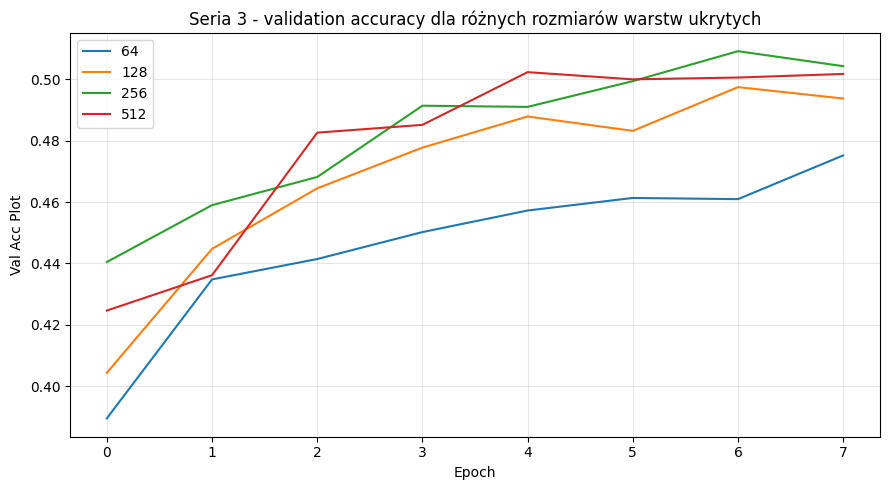

In [13]:
plot_series_histories(
    hidden_results.rename(columns={'history_val_loss': 'val_loss_plot'}).assign(val_loss_plot=hidden_results['history_val_loss']),
    'val_loss_plot',
    'Seria 3 - validation loss dla różnych rozmiarów warstw ukrytych'
)
plot_series_histories(
    hidden_results.rename(columns={'history_val_acc': 'val_acc_plot'}).assign(val_acc_plot=hidden_results['history_val_acc']),
    'val_acc_plot',
    'Seria 3 - validation accuracy dla różnych rozmiarów warstw ukrytych'
)

**Wniosek:** Zbyt mała liczba neuronów może ograniczać zdolność modelu do uczenia się, natomiast zbyt duża może zwiększać ryzyko przeuczenia. W praktyce najlepszy okazuje się zwykle model o średniej lub większej pojemności, ale niekoniecznie największy.

## 11. Seria 4 - wpływ dropout

To drugi eksperyment obowiązkowy dla grupy MLP. Porównuję brak dropoutu z dwiema wartościami regularyzacji, żeby ocenić wpływ na overfitting.

In [14]:
dropout_values = [0.0, 0.3, 0.5]
dropout_results = run_experiment_series(
    'dropout',
    dropout_values,
    lambda value: {'lr': 0.001, 'batch_size': 128, 'hidden1': 512, 'hidden2': 256, 'dropout': value},
    epochs=8
)
final_table(dropout_results)

dropout | 0.0 | val_acc=0.5256 | test_acc=0.5253
dropout | 0.3 | val_acc=0.5115 | test_acc=0.5085
dropout | 0.5 | val_acc=0.4779 | test_acc=0.4776


,label,best_val_acc,test_acc,test_loss,time_sec
0,0.0,0.5256,0.5253,1.4723,78.3
1,0.3,0.5115,0.5085,1.3920,78.5
2,0.5,0.4779,0.4776,1.4893,82.1


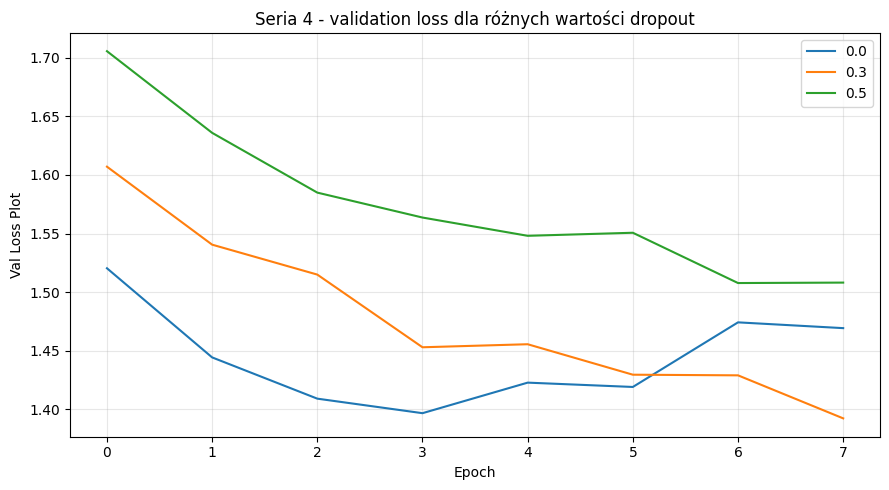

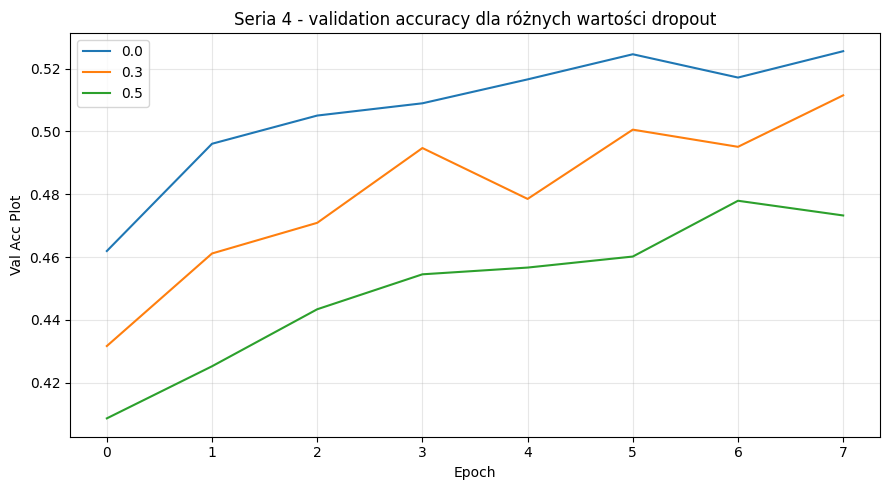

In [15]:
plot_series_histories(
    dropout_results.rename(columns={'history_val_loss': 'val_loss_plot'}).assign(val_loss_plot=dropout_results['history_val_loss']),
    'val_loss_plot',
    'Seria 4 - validation loss dla różnych wartości dropout'
)
plot_series_histories(
    dropout_results.rename(columns={'history_val_acc': 'val_acc_plot'}).assign(val_acc_plot=dropout_results['history_val_acc']),
    'val_acc_plot',
    'Seria 4 - validation accuracy dla różnych wartości dropout'
)

**Wniosek:** Dropout pomaga ograniczać przeuczenie, ale zbyt duża wartość może osłabić zdolność modelu do nauki. Najkorzystniejsza wartość zostanie wybrana na podstawie test accuracy i zachowania krzywych walidacyjnych.

## 12. Porównanie wszystkich serii eksperymentów

Łączę wyniki wszystkich eksperymentów w jedną tabelę, żeby łatwiej wskazać najlepszą konfigurację modelu.

In [16]:
all_results = pd.concat([lr_results, batch_results, hidden_results, dropout_results], ignore_index=True)
summary_table = all_results[['series', 'label', 'best_val_acc', 'test_acc', 'test_loss', 'time_sec']].copy()
summary_table['best_val_acc'] = summary_table['best_val_acc'].round(4)
summary_table['test_acc'] = summary_table['test_acc'].round(4)
summary_table['test_loss'] = summary_table['test_loss'].round(4)
summary_table['time_sec'] = summary_table['time_sec'].round(1)
summary_table.sort_values(by='test_acc', ascending=False).reset_index(drop=True)

,series,label,best_val_acc,test_acc,test_loss,time_sec
0,dropout,0.0000,0.5256,0.5253,1.4723,78.3
1,learning_rate,0.0001,0.5334,0.5246,1.3504,79.1
2,learning_rate,0.0010,0.5262,0.5100,1.3773,79.0
3,dropout,0.3000,0.5115,0.5085,1.3920,78.5
4,hidden_neurons,256.0000,0.5092,0.5074,1.4002,75.9
5,batch_size,128.0000,0.5070,0.5009,1.3954,77.0
6,hidden_neurons,512.0000,0.5023,0.4938,1.4429,77.7
7,batch_size,64.0000,0.4925,0.4908,1.4417,77.4
8,hidden_neurons,128.0000,0.4975,0.4895,1.4362,75.9
9,dropout,0.5000,0.4779,0.4776,1.4893,82.1


## 13. Wybór najlepszego modelu

Najlepszy model wybieram na podstawie accuracy na zbiorze testowym. Następnie dla tej konfiguracji obliczam dokładniejsze metryki: accuracy, confusion matrix oraz classification report.

In [17]:
best_idx = all_results['test_acc'].idxmax()
best_row = all_results.loc[best_idx]
print('Najlepsza seria:', best_row['series'])
print('Najlepsza wartość:', best_row['label'])
print('Konfiguracja:', best_row['config'])
print('Test accuracy:', round(best_row['test_acc'], 4))

Najlepsza seria: dropout
Najlepsza wartość: 0.0
Konfiguracja: {'lr': 0.001, 'batch_size': 128, 'hidden1': 512, 'hidden2': 256, 'dropout': 0.0}
Test accuracy: 0.5253


In [18]:
best_model = MLPClassifier(
    hidden1=best_row['config'].get('hidden1', 512),
    hidden2=best_row['config'].get('hidden2', 256),
    dropout=best_row['config'].get('dropout', 0.3)
).to(device)
best_model.load_state_dict(best_row['model_state_dict'])

best_batch_size = best_row['config'].get('batch_size', 128)
_, _, best_test_loader = get_loaders_for_batch_size(best_batch_size)
criterion = nn.CrossEntropyLoss()
best_test_loss, best_test_acc, best_preds, best_labels = evaluate(best_model, best_test_loader, criterion, device)
acc, report_dict, matrix = model_metrics(best_labels, best_preds, class_names)

print('Accuracy:', round(acc, 4))
report_df = pd.DataFrame(report_dict).transpose()
report_df

Accuracy: 0.5256


,precision,recall,f1-score,support
airplane,0.548253,0.6590,0.598547,1000.0000
automobile,0.632075,0.6030,0.617195,1000.0000
bird,0.421000,0.4210,0.421000,1000.0000
cat,0.394704,0.3130,0.349136,1000.0000
deer,0.429973,0.4820,0.454503,1000.0000
dog,0.431866,0.4120,0.421699,1000.0000
frog,0.588050,0.5610,0.574207,1000.0000
horse,0.628176,0.5440,0.583065,1000.0000
ship,0.613678,0.6640,0.637848,1000.0000
truck,0.555866,0.5970,0.575699,1000.0000


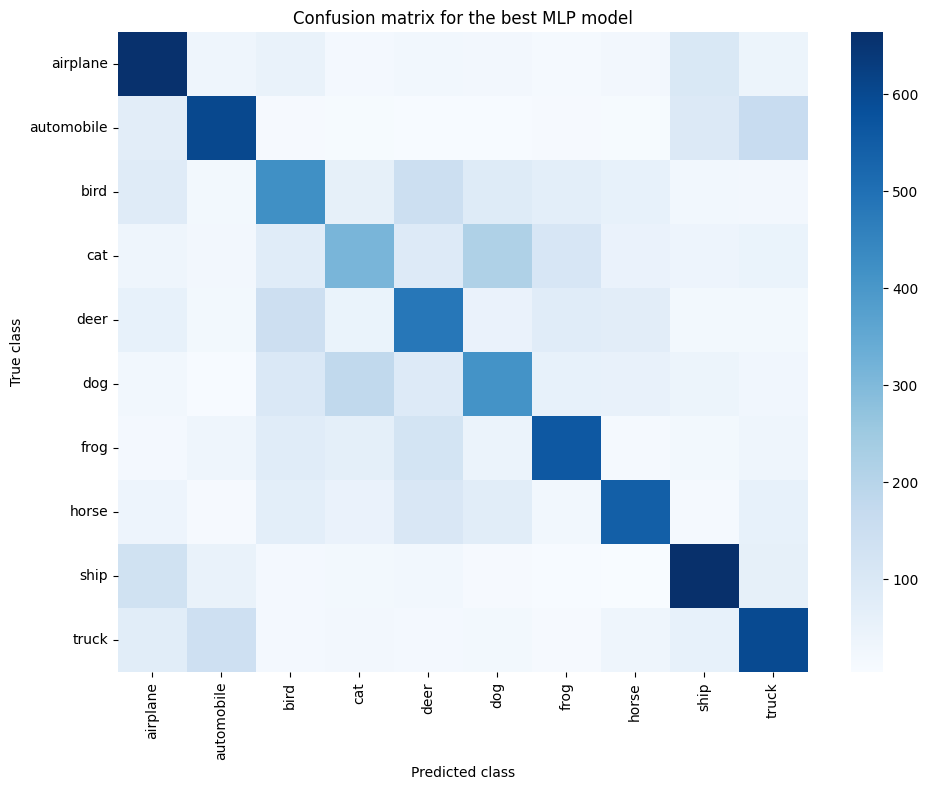

In [19]:
plot_confusion_matrix(matrix, class_names)

## 14. Przykłady błędnie sklasyfikowanych obrazów

Na końcu pokazuję przykłady błędnych predykcji. Taka analiza pozwala zobaczyć, które klasy są do siebie podobne i gdzie model ma największy problem.

c:\Users\Michał\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


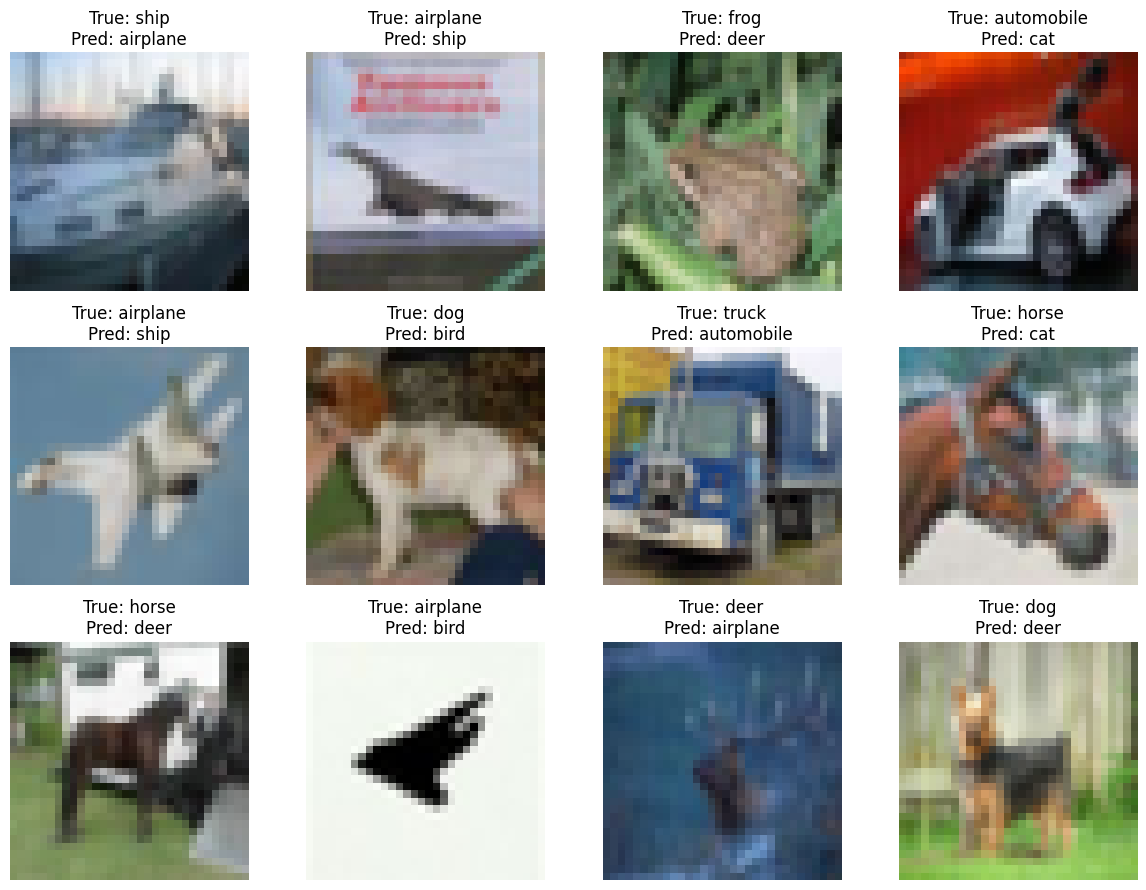

In [20]:
from torchvision import datasets, transforms

raw_test = datasets.CIFAR10(root='data', train=False, download=True, transform=transforms.ToTensor())
mis_images = []
mis_true = []
mis_pred = []

for i in range(len(raw_test)):
    image, label = raw_test[i]
    input_image = ((image - torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)) / torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = best_model(input_image).argmax(dim=1).item()
    if pred != label:
        mis_images.append(image.numpy())
        mis_true.append(label)
        mis_pred.append(pred)
    if len(mis_images) >= 12:
        break

show_misclassified(mis_images, mis_true, mis_pred, class_names, max_images=12)

## 15. Wnioski końcowe

1. Model MLP potrafi klasyfikować obrazy CIFAR-10, ale jego skuteczność jest ograniczona, ponieważ nie wykorzystuje lokalnej struktury obrazu tak jak sieci CNN.
2. Na wynik końcowy wyraźnie wpływają learning rate, batch size oraz liczba neuronów w warstwach ukrytych.
3. Dropout pomaga ograniczyć przeuczenie, ale jego zbyt duża wartość może pogorszyć accuracy.
4. Najwięcej pomyłek zwykle pojawia się między klasami o podobnym wyglądzie, na przykład cat i dog albo automobile i truck.
5. Z punktu widzenia zadania najlepszy model został wybrany na podstawie metryk ilościowych i dodatkowo przeanalizowany jakościowo za pomocą confusion matrix oraz przykładów błędnych klasyfikacji.